In [1]:

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")



In [2]:
df = pd.read_csv(r"L:\python\eisystems\project1\covid19.csv")

In [3]:
df.head()

,Country/Region,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,Deaths / 100 Cases,Recovered / 100 Cases,Deaths / 100 Recovered,Confirmed last week,1 week change,1 week % increase,WHO Region
0,Afghanistan,36263,1269,25198,9796,106,10,18,3.50,69.49,5.04,35526,737,2.07,Eastern Mediterranean
1,Albania,4880,144,2745,1991,117,6,63,2.95,56.25,5.25,4171,709,17.00,Europe
2,Algeria,27973,1163,18837,7973,616,8,749,4.16,67.34,6.17,23691,4282,18.07,Africa
3,Andorra,907,52,803,52,10,0,0,5.73,88.53,6.48,884,23,2.60,Europe
4,Angola,950,41,242,667,18,1,0,4.32,25.47,16.94,749,201,26.84,Africa


In [4]:
df.head()

,Country/Region,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,Deaths / 100 Cases,Recovered / 100 Cases,Deaths / 100 Recovered,Confirmed last week,1 week change,1 week % increase,WHO Region
0,Afghanistan,36263,1269,25198,9796,106,10,18,3.50,69.49,5.04,35526,737,2.07,Eastern Mediterranean
1,Albania,4880,144,2745,1991,117,6,63,2.95,56.25,5.25,4171,709,17.00,Europe
2,Algeria,27973,1163,18837,7973,616,8,749,4.16,67.34,6.17,23691,4282,18.07,Africa
3,Andorra,907,52,803,52,10,0,0,5.73,88.53,6.48,884,23,2.60,Europe
4,Angola,950,41,242,667,18,1,0,4.32,25.47,16.94,749,201,26.84,Africa


In [5]:
df.columns

Index(['Country/Region', 'Confirmed', 'Deaths', 'Recovered', 'Active',
       'New cases', 'New deaths', 'New recovered', 'Deaths / 100 Cases',
       'Recovered / 100 Cases', 'Deaths / 100 Recovered',
       'Confirmed last week', '1 week change', '1 week % increase',
       'WHO Region'],
      dtype='object')

data overview

In [6]:
print("Dataset Shape:", df.shape)
print("\nColumn Names:\n", df.columns)
print("\nData Info:\n")
df.info()


Dataset Shape: (187, 15)

Column Names:
 Index(['Country/Region', 'Confirmed', 'Deaths', 'Recovered', 'Active',
       'New cases', 'New deaths', 'New recovered', 'Deaths / 100 Cases',
       'Recovered / 100 Cases', 'Deaths / 100 Recovered',
       'Confirmed last week', '1 week change', '1 week % increase',
       'WHO Region'],
      dtype='object')

Data Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 187 entries, 0 to 186
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Country/Region          187 non-null    object 
 1   Confirmed               187 non-null    int64  
 2   Deaths                  187 non-null    int64  
 3   Recovered               187 non-null    int64  
 4   Active                  187 non-null    int64  
 5   New cases               187 non-null    int64  
 6   New deaths              187 non-null    int64  
 7   New recovered           187 non-null    int64

#check missing values

In [7]:
print("Missing values:\n")
df.isnull().sum()


Missing values:



Country/Region            0
Confirmed                 0
Deaths                    0
Recovered                 0
Active                    0
New cases                 0
New deaths                0
New recovered             0
Deaths / 100 Cases        0
Recovered / 100 Cases     0
Deaths / 100 Recovered    0
Confirmed last week       0
1 week change             0
1 week % increase         0
WHO Region                0
dtype: int64

#select features and target

In [8]:
X = df[['Confirmed', 'Deaths', 'Recovered']]
y = df['Active']

X.head(), y.head()


(   Confirmed  Deaths  Recovered
 0      36263    1269      25198
 1       4880     144       2745
 2      27973    1163      18837
 3        907      52        803
 4        950      41        242,
 0    9796
 1    1991
 2    7973
 3      52
 4     667
 Name: Active, dtype: int64)

#splitting of data

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train size:", len(X_train))
print("Test size:", len(X_test))


Train size: 149
Test size: 38


train model

In [10]:
model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained successfully!")


Model trained successfully!


predictions

In [11]:
y_pred = model.predict(X_test)

comparison = pd.DataFrame({
    'Actual Active': y_test.values,
    'Predicted Active': y_pred
})

comparison.head(10)


,Actual Active,Predicted Active
0,1597,1.597000e+03
1,21,2.100000e+01
2,74,7.400000e+01
3,17902,1.790200e+04
4,73695,7.369500e+04
5,6221,6.221000e+03
6,0,6.546941e-11
7,170537,1.705370e+05
8,839,8.390000e+02
9,28258,2.825800e+04


model evaluation

In [12]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Evaluation Metrics:")
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R² Score:", r2)


Evaluation Metrics:
MAE: 9.570447358585529e-11
MSE: 2.5013874264391602e-20
RMSE: 1.5815775119921123e-10
R² Score: 1.0


visualization

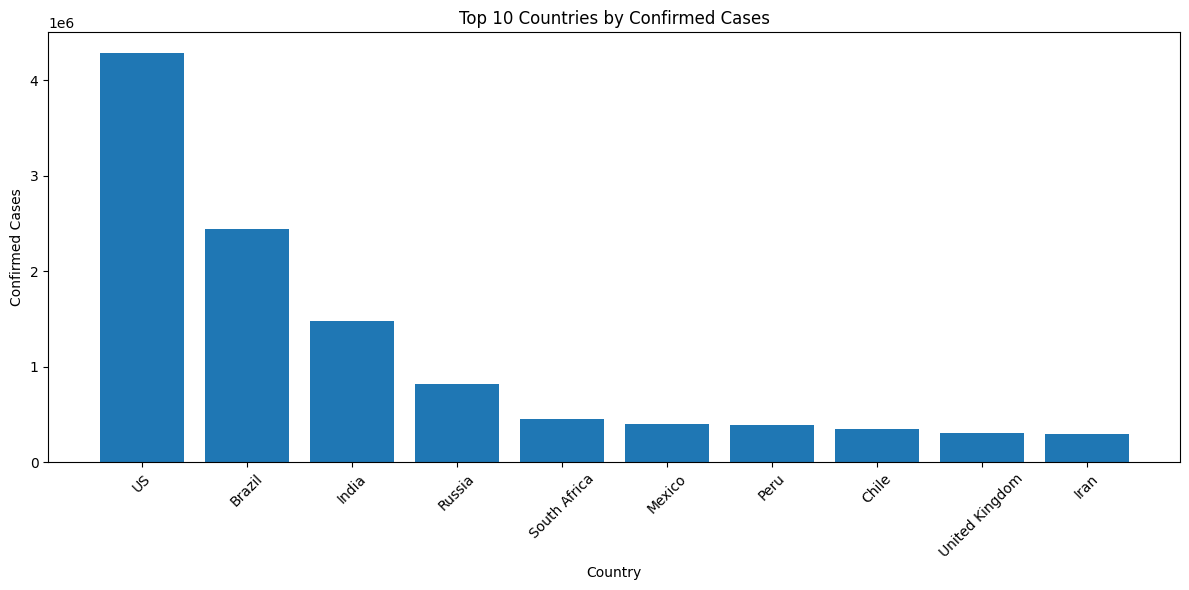

In [14]:
import matplotlib.pyplot as plt
top10_confirmed = df.sort_values(by='Confirmed', ascending=False).head(10)

plt.figure(figsize=(12,6))
plt.bar(top10_confirmed['Country/Region'], top10_confirmed['Confirmed'])
plt.title("Top 10 Countries by Confirmed Cases")
plt.xlabel("Country")
plt.ylabel("Confirmed Cases")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


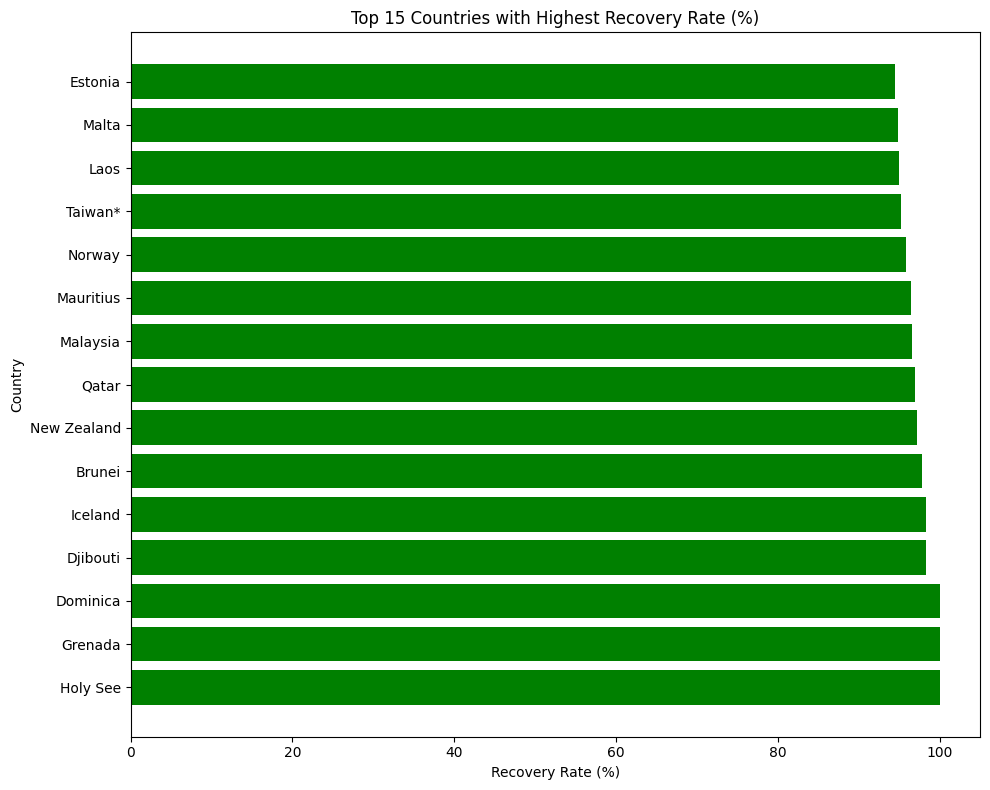

In [15]:
top15_recovery = df.sort_values(by='Recovered / 100 Cases', ascending=False).head(15)
plt.figure(figsize=(10,8))
plt.barh(top15_recovery['Country/Region'], top15_recovery['Recovered / 100 Cases'], 
         color='green')
plt.title("Top 15 Countries with Highest Recovery Rate (%)")
plt.xlabel("Recovery Rate (%)")
plt.ylabel("Country")
plt.tight_layout()
plt.show()


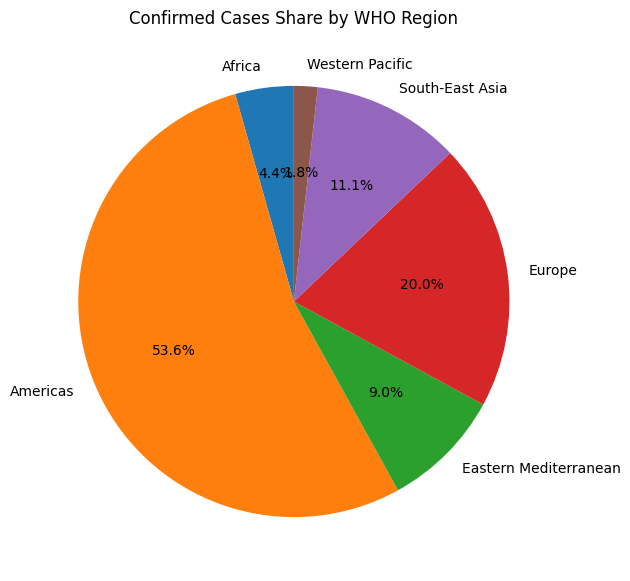

In [16]:
region_cases = df.groupby("WHO Region")['Confirmed'].sum()

plt.figure(figsize=(7,7))
plt.pie(region_cases, labels=region_cases.index, autopct='%1.1f%%', startangle=90)
plt.title("Confirmed Cases Share by WHO Region")
plt.show()


In [17]:
df.head()

,Country/Region,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,Deaths / 100 Cases,Recovered / 100 Cases,Deaths / 100 Recovered,Confirmed last week,1 week change,1 week % increase,WHO Region
0,Afghanistan,36263,1269,25198,9796,106,10,18,3.50,69.49,5.04,35526,737,2.07,Eastern Mediterranean
1,Albania,4880,144,2745,1991,117,6,63,2.95,56.25,5.25,4171,709,17.00,Europe
2,Algeria,27973,1163,18837,7973,616,8,749,4.16,67.34,6.17,23691,4282,18.07,Africa
3,Andorra,907,52,803,52,10,0,0,5.73,88.53,6.48,884,23,2.60,Europe
4,Angola,950,41,242,667,18,1,0,4.32,25.47,16.94,749,201,26.84,Africa


In [18]:
print("===== Predict Active Cases =====")

confirmed = float(input("Enter Confirmed cases: "))
deaths = float(input("Enter Deaths: "))
recovered = float(input("Enter Recovered: "))

user_input = np.array([[confirmed, deaths, recovered]])
result = model.predict(user_input)[0]

print(f"Predicted Active Cases: {result:.2f}")


===== Predict Active Cases =====


Enter Confirmed cases:  3452
Enter Deaths:  1223
Enter Recovered:  655


Predicted Active Cases: 1574.00


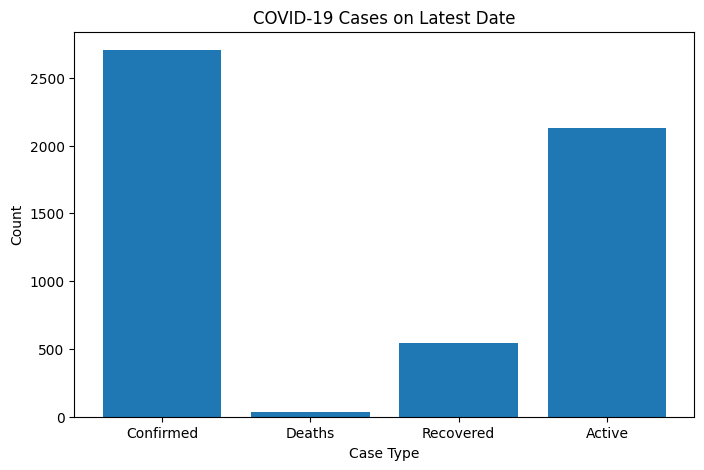

In [19]:
import matplotlib.pyplot as plt

# Select last row values
latest = df.iloc[-1]
categories = ['Confirmed', 'Deaths', 'Recovered', 'Active']
values = latest[['Confirmed', 'Deaths', 'Recovered', 'Active']]

plt.figure(figsize=(8,5))
plt.bar(categories, values)
plt.title("COVID-19 Cases on Latest Date")
plt.xlabel("Case Type")
plt.ylabel("Count")
plt.show()


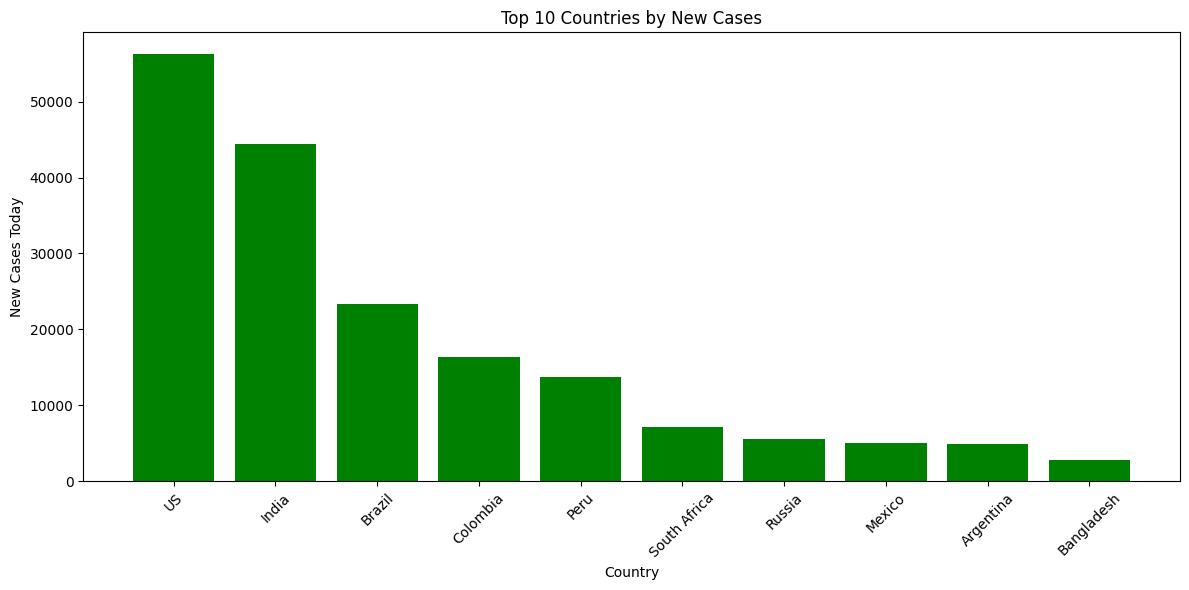

In [20]:
top10_new = df.sort_values(by='New cases', ascending=False).head(10)

plt.figure(figsize=(12,6))
plt.bar(top10_new['Country/Region'], top10_new['New cases'], color='green')
plt.title("Top 10 Countries by New Cases")
plt.xlabel("Country")
plt.ylabel("New Cases Today")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


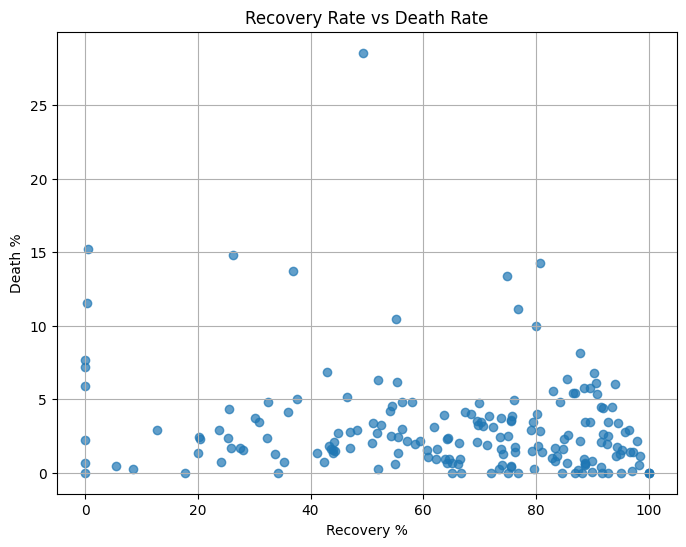

In [21]:
plt.figure(figsize=(8,6))
plt.scatter(df['Recovered / 100 Cases'], df['Deaths / 100 Cases'], alpha=0.7)
plt.title("Recovery Rate vs Death Rate")
plt.xlabel("Recovery %")
plt.ylabel("Death %")
plt.grid(True)
plt.show()


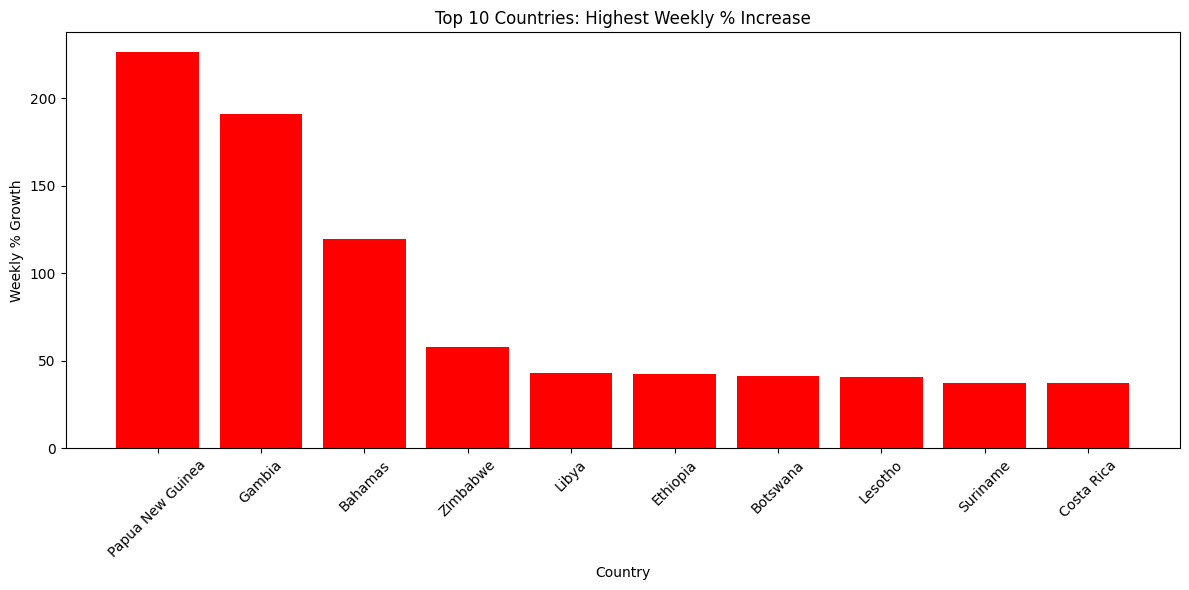

In [22]:
top10_growth = df.sort_values(by='1 week % increase', ascending=False).head(10)

plt.figure(figsize=(12,6))
plt.bar(top10_growth['Country/Region'], top10_growth['1 week % increase'], color='red')
plt.title("Top 10 Countries: Highest Weekly % Increase")
plt.xlabel("Country")
plt.ylabel("Weekly % Growth")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


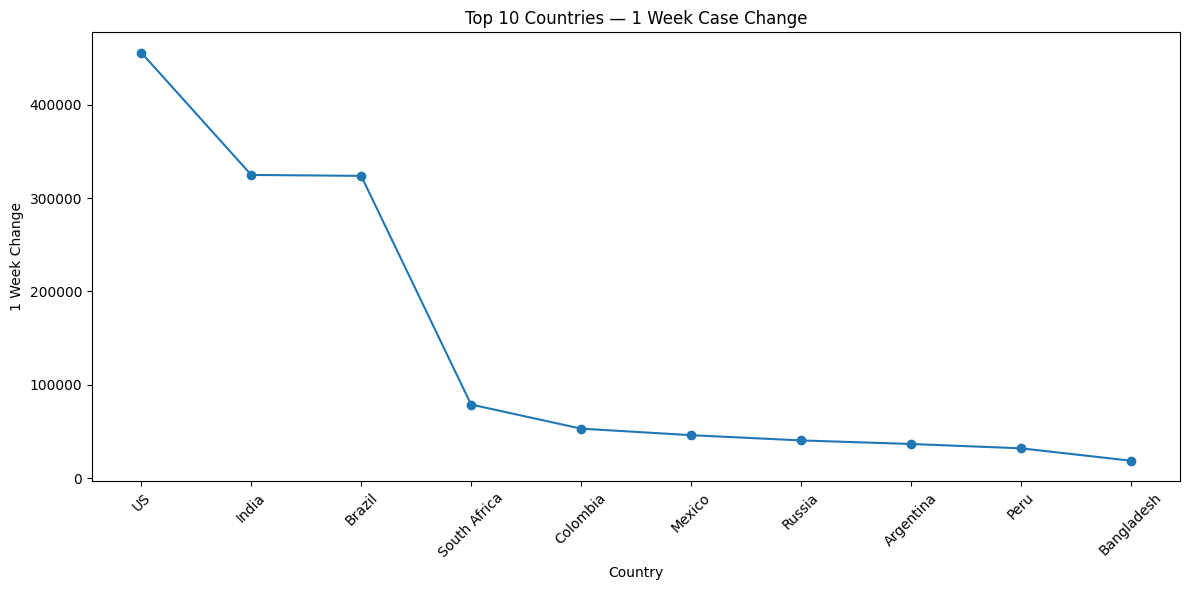

In [23]:
top10_change = df.sort_values(by='1 week change', ascending=False).head(10)

plt.figure(figsize=(12,6))
plt.plot(top10_change['Country/Region'], top10_change['1 week change'], marker='o')
plt.title("Top 10 Countries — 1 Week Case Change")
plt.xlabel("Country")
plt.ylabel("1 Week Change")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
